In [11]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

from aim_resolve import plot_arrays, plot_classes

n objects: 3
n noise points: 4


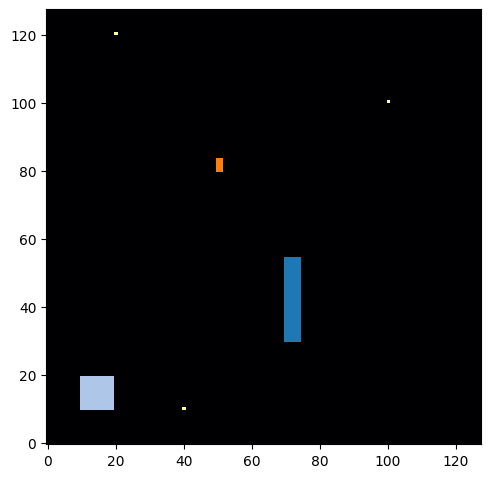

n objects: 3
n noise points: 0
n points: 3


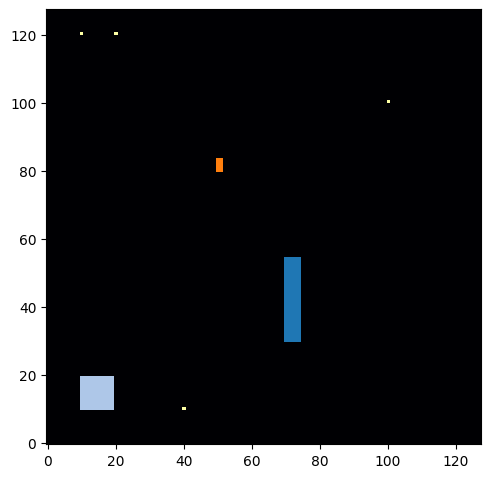

In [ ]:
def clustering(objects_map, print_cl=True, **cl_kwargs):
    '''
    function to cluster the extended objects in the output map of the U-Net.

    Parameters
    ----------
    objects_map : np.ndarray
        The objects map of the U-Net.
    print_clu : bool
        Whether to print the number of detected objects and noise points. Default is True.
    **cl_kwargs
        Necessary keyword arguments for the clustering method.

    Returns
    -------
    cluster_maps : np.ndarray
        An array of output maps, one for each detected object.
    noise_map : np.ndarray
        One output map containing the noise points.
    '''
    # extract locations of the extended objects from the output map
    X = np.argwhere(objects_map == 1)

    # check if there are any objects to cluster, if not return empty array
    if X.size == 0:
        if print_cl:
            print('n objects:', 0)
            print('n noise points:', 0)
        return np.zeros((0,) + objects_map.shape)
    
    # initialize clustering method
    cl_alg = DBSCAN(**cl_kwargs)
    
    # scale input and apply selected clustering method
    X_scaled = StandardScaler().fit_transform(X)
    clu = cl_alg.fit(X_scaled)
    labels = clu.labels_

    # get number of detected objects and noise points
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    # print number of detected objects and noise points
    if print_cl:
        print(f'n objects: {n_clusters}')
        print('n noise points: %d' % n_noise)

    # create one output map for each detected object and an empty map for the background
    cluster_maps = np.zeros((n_clusters,) + objects_map.shape)
    for k in range(n_clusters):
        mask = labels == k
        loc = X[mask].T
        cluster_maps[k][loc[0], loc[1]] = 1

    # sort the cluster maps by the sizes of the objects in descending order
    ones_count = np.sum(cluster_maps, axis=(1, 2))
    sorted_indices = np.argsort(-ones_count)
    cluster_maps = cluster_maps[sorted_indices]

    # create a map for the noise points
    noise_map = np.zeros_like(objects_map)
    mask = labels == -1
    loc = X[mask].T
    noise_map[loc[0], loc[1]] = 1

    return cluster_maps, noise_map



def objects2points(points_map, noise_map, print_ps=True, **cl_kwargs):
    '''
    function to add one-pixel sized objects to the points map.

    Parameters
    ----------
    points_map : np.ndarray
        The points map of the U-Net.
    noise_map : np.ndarray
        The noise map of clustering.
    print_ps : bool
        Whether to print the number of points in the points map. Default is True.
    **cl_kwargs
        Necessary keyword arguments for the clustering method.
    
    Returns
    -------
    points_map : np.ndarray
        The updated points map with noise points converted to points.
    '''
    if np.sum(noise_map) == 0:
        if print_ps:
            print('n points:', np.sum(points_map == 1))
        return points_map
    
    cl_kwargs.pop('min_samples', None)
    noise_maps, _ = clustering(noise_map, min_samples=1, **cl_kwargs)
    mask = np.sum(noise_maps == 1, axis=(1, 2)) == 1
    add_points = np.sum(noise_maps[mask], axis=0)

    points_map += add_points

    if print_ps:
        print('n points:', np.sum(points_map == 1))

    return points_map.clip(0, 1)
 


ps_map = np.zeros((128, 128))
ps_map[100,100] = 1
ps_map[20,120] = 1
ps_map[40,10] = 1

a = np.zeros((128,128))
a[10:20, 10:20] = 1
a[70:75, 30:55] = 1
a[50:52, 80:84] = 1
a[30,30:32] = 1  
a[100,100] = 1
a[10,120] = 1  

oj_map, ns_map = clustering(a, eps=0.1, min_samples=4, print_cl=True)
plot_classes(ps_map, oj_map, dpi=100)

ps_map = objects2points(ps_map, ns_map, eps=0.1, min_samples=4, print_ps=True)
plot_classes(ps_map, oj_map, dpi=100)